<a href="https://colab.research.google.com/github/FarjanaAkterLaila/Advanced_Sarcasm_Detection-_and-_Analyzing_Formal-Informal_Languages_using_Transformed-Based-Models/blob/main/For_Mixed_Language_using_Roberta_Distilbert_Albert_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data


In [ ]:
import pandas as pd
df = pd.read_csv("/content/split dataset-original.csv")
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [ ]:
len(df['headline'].values)

10003

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re
import nltk
from nltk import word_tokenize
import numpy as np

In [ ]:
import re  # Import the 're' module for regular expressions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# 2. Text Cleaning Function (with URL handling)
def clean_text(text):
    # Convert the input to a string if it is not already.
    if not isinstance(text, str):
        text = str(text)

    text = re.sub(r"http\S+|www\S+|https\S+", " [LINK] ", text, flags=re.MULTILINE)

    text = re.sub('[^a-zA-Z]', ' ', text).lower()

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
print(clean_text(df['headline'][0]))

former versace store clerk sues over secret black code for minority shoppers


In [ ]:
df['cleaned_headlines'] = df['headline'].apply(lambda x: clean_text(x))

In [ ]:
df.shape

(10003, 4)

In [ ]:
# reduced_sarcasm_df = df.head(10000)

In [ ]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5558
1,4445


In [ ]:
# Check for missing values in the DataFrame, not the list
print('missing value for formal dataset :' ,df['headline'].isnull().sum())

# # Remove duplicates if any, directly from the DataFrame
# df.drop_duplicates(subset=['headline'], inplace=True)
duplicates = df['headline'].duplicated().sum()
print(f"Number of duplicate headlines: {duplicates}")



missing value for formal dataset : 0
Number of duplicate headlines: 21


In [ ]:
# Find duplicated headlines and display them
duplicated_texts = df[df['headline'].duplicated(keep=False)]['headline']

# Display the duplicated texts
print("Duplicated headlines:")
for i, text in enumerate(duplicated_texts.unique(), 1):
    print(f"{i}. {text}")

Duplicated headlines:
1. antarctic observational comic running out of ideas
2. the best chance to defeat roy moore may be for the democratic party to lie low
3. loser can't even get wife pregnant
4. area man killed in committee
5. sunday roundup
6. sole remaining lung filled with rich, satisfying flavor
7. all y'all urged to go fuck yo' selves
8. bird has big plans for cage
9. saturday's morning email: funnies edition
10. willow rented
11. personal philosophy stolen from martin luther king jr.
12. magical gallery transforms dull objects into art
13. systems administrator would so fuck new trainee
14. the 20 funniest tweets from women this week
15. the funniest tweets from women this week
16. 5 things everyone gets wrong about napping
17. neighbors remember serial killer as serial killer


In [ ]:
df.drop_duplicates(subset=['headline'], inplace=True)

In [ ]:
len(df['headline'].values)

9982

In [ ]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5548
1,4434


### labeling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

def balance_df(df, text, target):
    ros = RandomOverSampler()
    train_x, train_y = ros.fit_resample(np.array(df[text]).reshape(-1,1), np.array(df[target]).reshape(-1,1))
    new_df = pd.DataFrame(list(zip([x[0] for x in train_x], train_y)), columns = [text, target])

    return new_df


sarcasm_df = pd.DataFrame()
sarcasm_df = balance_df(df, 'cleaned_headlines', 'is_sarcastic')

In [ ]:
print(sarcasm_df['cleaned_headlines'][0])

former versace store clerk sues over secret black code for minority shoppers


In [ ]:
sarcasm_df.head()

,cleaned_headlines,is_sarcastic
0,former versace store clerk sues over secret bl...,0
1,the roseanne revival catches up to our thorny ...,0
2,mom starting to fear son s web series closest ...,1
3,boehner just wants wife to listen not come up ...,1
4,j k rowling wishes snape happy birthday in the...,0


In [ ]:
sarcasm_df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5548
1,5548


## Split Data

In [ ]:
X = sarcasm_df["cleaned_headlines"]
y = sarcasm_df['is_sarcastic']

# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Split data into train, validation, and test sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    X, y, test_size=0.20, random_state=42
)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    train_texts, train_labels, test_size=0.20, random_state=42
)

In [ ]:
train_texts.shape, val_texts.shape, train_labels.shape, val_labels.shape,test_texts.shape, test_labels.shape

((7100,), (2220,), (7100,), (2220,), (1776,), (1776,))

## Roberta model

In [ ]:
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification

# Load tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model= TFRobertaForSequenceClassification.from_pretrained('roberta-base')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [ ]:
max_length = max(len(text) for text in df['cleaned_headlines'])
max_length

187

In [ ]:
train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# train_encodings = tokenizer(X_train.tolist(), padding=True, truncation=True, max_length=max_length)
train_encodings

{'input_ids': [[0, 2413, 2583, 939, 475, 164, 7, 109, 99, 939, 64, 149, 1031, 814, 15, 2447, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1794, 2202, 8409, 3553, 76, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 16244, 12094, 8206, 2500, 1929, 9, 1717, 579, 790, 9, 4844, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 463, 10461, 784, 37654, 40, 146, 47, 1034, 13, 910, 1758, 579, 744, 1310, 15, 5, 3051, 1462, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 428, 12145, 8842, 419, 7, 278, 62, 194, 9, 5, 2918, 11048, 3563, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 438, 33028, 4211, 5940, 4835, 12988, 9, 514, 228, 76, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 28752, 1269, 9, 3486, 1970, 1516, 4976, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 17409, 579, 2

In [ ]:
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# test_encodings = tokenizer(X_test.tolist(), padding=True, truncation=True, max_length=max_length)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))
# train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
# test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(37,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(37,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# max_length=130

In [ ]:
# Define custom model architecture
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

# RoBERTa output
roberta_output = model(input_ids, attention_mask=attention_mask)
logits = roberta_output.logits

# Add custom dense layers
x = tf.keras.layers.Dense(256, activation='relu')(logits)
x = tf.keras.layers.Dropout(0.3)(x)  # Dropout layer for regularization
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)  # Dropout layer for regularization

# Output layer with two units for binary classification
output = tf.keras.layers.Dense(2, activation='softmax')(x)

# Create the model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile the model with optimizer and loss function
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)  # Adjust the learning rate for fine-tuning
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Display the model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_for_sequence_cl  TFSequenceClassifierOutput   1246471   ['input_ids[0][0]',           
 assification (TFRobertaFor  (loss=None, logits=(None,    70         'attention_mask[0][0]']      
 SequenceClassification)     2),                                                              

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
# loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [ ]:
# test_encodings = tokenizer(
#     X_test.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=max_length  # Use the correct max_length here
# )

In [ ]:
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=8,
    validation_data=val_dataset.batch(16)
    # validation_data=test_dataset.batch(16)
)


Epoch 1/4
444/444 [==============================] - 121s 176ms/step - loss: 0.4523 - accuracy: 0.7773 - val_loss: 0.3345 - val_accuracy: 0.8752
Epoch 2/4
444/444 [==============================] - 70s 157ms/step - loss: 0.2400 - accuracy: 0.9093 - val_loss: 0.2609 - val_accuracy: 0.9041
Epoch 3/4
444/444 [==============================] - 70s 158ms/step - loss: 0.1471 - accuracy: 0.9517 - val_loss: 0.3274 - val_accuracy: 0.8955
Epoch 4/4
444/444 [==============================] - 69s 156ms/step - loss: 0.0823 - accuracy: 0.9745 - val_loss: 0.3870 - val_accuracy: 0.8986


In [ ]:
# model.summary()

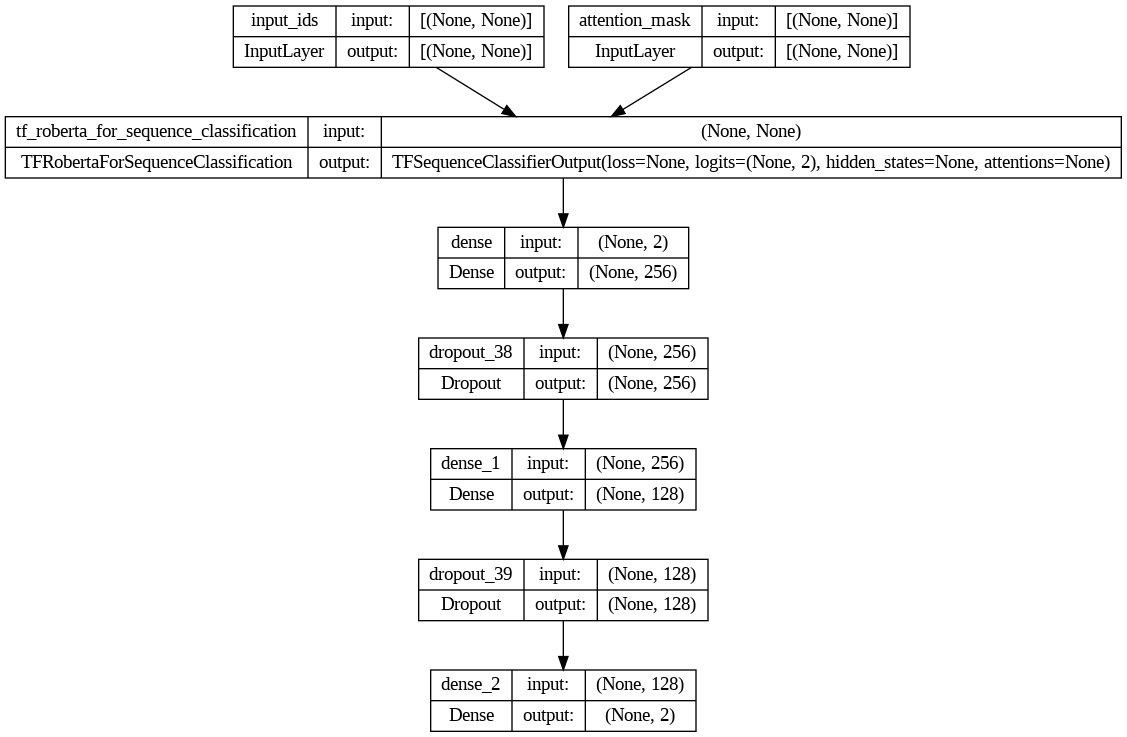

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Roberta model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


139/139 [==============================] - 10s 44ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1109
           1       0.93      0.86      0.89      1111

    accuracy                           0.90      2220
   macro avg       0.90      0.90      0.90      2220
weighted avg       0.90      0.90      0.90      2220

111/111 [==============================] - 9s 54ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       866
           1       0.94      0.87      0.90       910

    accuracy                           0.91      1776
   macro avg       0.91      0.91      0.91      1776
weighted avg       0.91      0.91      0.91      1776

Validation Accuracy: 0.8986
Test Accuracy: 0.9060


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:

# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

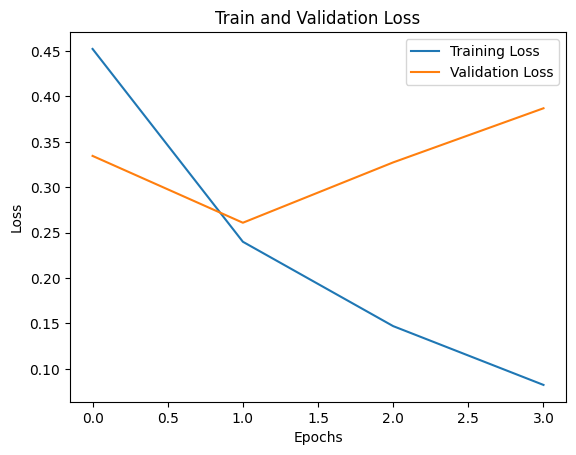

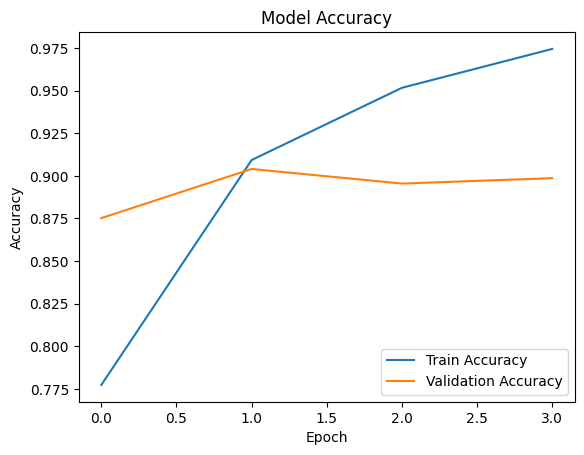

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

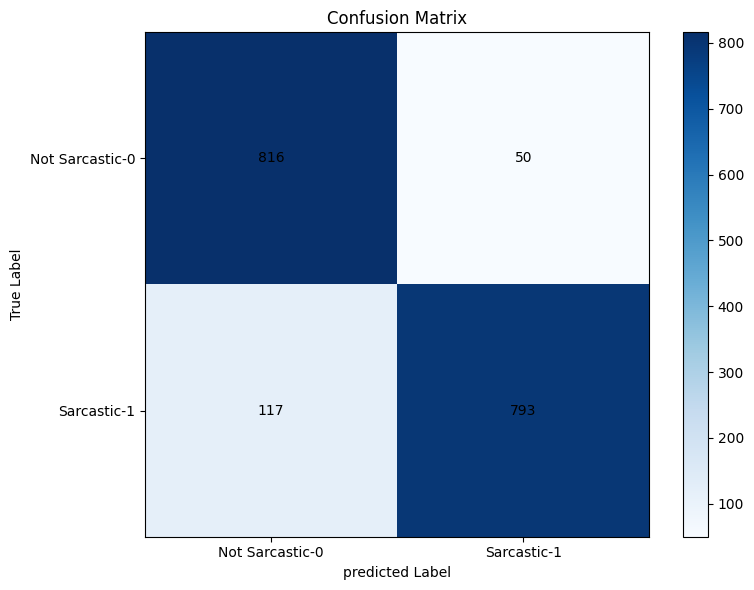

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming 'test_labels' and 'test_preds' are your true and predicted labels for the test set
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])
# plt.yticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

In [ ]:
# # test_preds = model.predict(test_texts)
# # Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
# Create a DataFrame with true and predicted labels
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
3523,0,0,let s get trump s evangelical council to resign
10016,1,1,westboro baptist church not really sure why th...
10049,1,1,boyfriend forced to express secondhand outrage
7524,0,0,a small senate victory maintains methane regul...
4240,0,0,ruth bader ginsburg abortion restrictions most...
4603,0,0,creating a chemically free home is easier and ...
7436,1,0,hillary clinton inspires young girls to form p...
2727,1,1,wrong turn finds man on poor side of mall
2066,0,0,unesco weighs in on debate over where jesus wa...
8540,1,1,compliment suspiciously vague


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

111/111 [==============================] - 6s 53ms/step


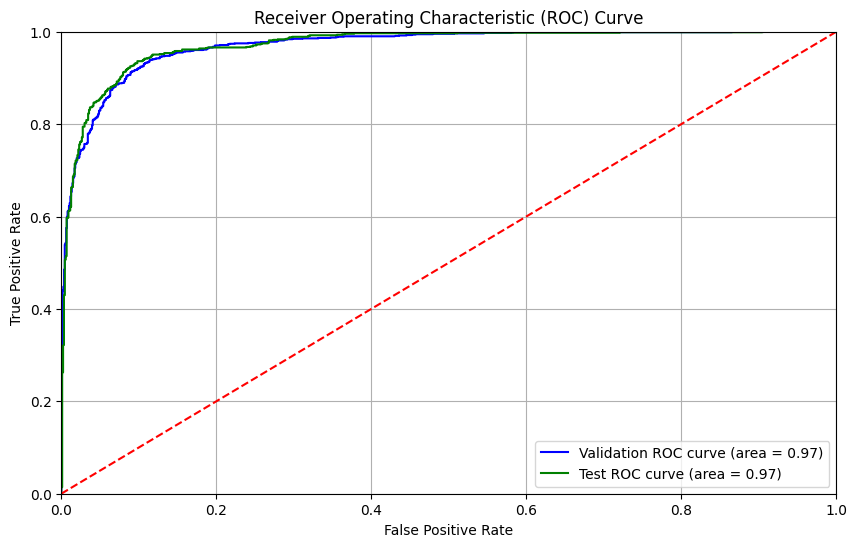

In [ ]:
# from sklearn.metrics import roc_auc_score, roc_curve, auc

# # Calculate probabilities of the positive class (sarcastic)
# y_probs = model.predict(test_dataset.batch(16))
# y_prob_positive = y_probs[:, 1]  # Probabilities for class 'sarcastic'

# # Calculate the ROC-AUC score
# roc_auc = roc_auc_score(test_labels, y_prob_positive)
# print("ROC-AUC Score:", roc_auc)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()




In [ ]:
# # Compute ROC curve and AUC
# fpr, tpr, thresholds = roc_curve(test_labels, y_prob_positive)
# roc_auc = auc(fpr, tpr)

# # Plot ROC Curve
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='blue', label=f"RoBERTa Model (AUC = {roc_auc:.2f})")
# plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for reference
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend(loc="lower right")
# plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
# from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# # Log Loss Calculation
# logloss = log_loss(test_labels, y_probs)
# print("Log Loss:", logloss)



import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.4102
Validation MCC: 0.8000
Validation Cohen's Kappa Score: 0.7973
Validation Brier Score: 0.1172
Test Log Loss: 0.4049
Test MCC: 0.8145
Test Cohen's Kappa Score: 0.8122
Test Brier Score: 0.1148


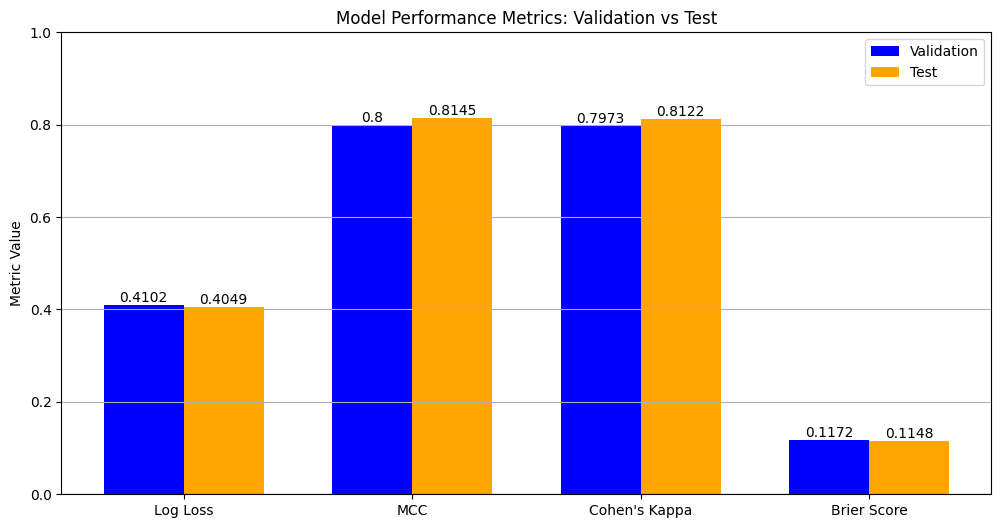

In [ ]:
# # Matthews Correlation Coefficient Calculation
# mcc = matthews_corrcoef(test_labels, test_preds)
# print("Matthews Correlation Coefficient:", mcc)
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()


In [ ]:

# # Cohen's Kappa Score Calculation
# kappa = cohen_kappa_score(test_labels, test_preds)
# print("Cohen's Kappa Score:", kappa)





In [ ]:
# # Brier Score Calculation
# brier_score = brier_score_loss(test_labels, y_prob_positive)
# print("Brier Score:", brier_score)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define metrics and their values for plotting
# metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']
# values = [logloss, mcc, kappa, brier_score]

# # Create bar plot
# plt.figure(figsize=(10, 6))
# bars = plt.bar(metrics, values, color=['red', 'blue', 'green', 'orange'])

# # Add labels and title
# plt.ylabel('Metric Value')
# plt.title('Model Performance Metrics')

# # Show value on top of each bar
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

# plt.ylim(0, 1)
# plt.axhline(0, color='black', linewidth=0.8)
# plt.grid(axis='y')
# plt.show()


# Albert

In [ ]:
from transformers import AlbertTokenizer, TFAlbertModel
# Load ALBERT tokenizer and model
tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')
albert_model = TFAlbertModel.from_pretrained('albert-base-v2')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFAlbertModel: ['predictions.LayerNorm.bias', 'predictions.bias', 'predictions.LayerNorm.weight', 'predictions.decoder.bias', 'predictions.dense.weight', 'predictions.dense.bias']
- This IS expected if you are initializing TFAlbertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFAlbertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFAlbertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFAlbertModel for predictions without further training.


In [ ]:
# Tokenize the data
train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=512)
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=512)
# train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=512)
# test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=512)

In [ ]:
train_encodings

{'input_ids': [[2, 7677, 31, 307, 228, 20, 107, 98, 31, 92, 120, 1452, 1028, 27, 6850, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 1329, 6257, 302, 10220, 24367, 5332, 35, 65, 85, 183, 363, 189, 288, 1691, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 515, 4539, 5817, 1204, 803, 16, 287, 13, 18, 191, 16, 2903, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 2376, 4086, 129, 233, 42, 1376, 26, 4163, 13, 18, 372, 1691, 27, 14, 2094, 828, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 1778, 3600, 12291, 18, 125, 5222, 18, 16, 414, 15756, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 25225, 5432, 12360, 4854, 15737, 16, 308, 416, 159, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 1621, 789, 16, 3796, 3049, 2488, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 2171, 13, 18, 131, 19679, 317, 565, 329, 20, 5737, 29, 14601, 208, 116, 15

In [ ]:
# # Convert encodings to TensorFlow datasets
# train_dataset = tf.data.Dataset.from_tensor_slices((
#     dict(train_encodings),
#      y_train
# ))
# test_dataset = tf.data.Dataset.from_tensor_slices((
#     dict(test_encodings),
#      y_test
# ))
# Convert encodings to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings),train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))

In [ ]:
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(34,), dtype=tf.int32, name=None), 'token_type_ids': TensorSpec(shape=(34,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(34,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# Define input layers for the ALBERT model
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

In [ ]:


# Get the hidden states from ALBERT
hidden_states = albert_model(input_ids, attention_mask=attention_mask).last_hidden_state

# Extract the [CLS] token representation
cls_token = hidden_states[:, 0, :]

# Custom dense and dropout layers
pooled_dense = tf.keras.layers.Dense(768, activation='relu', name='pooled_dense')(cls_token)
output_dropout = tf.keras.layers.Dropout(0.1, name='output_dropout')(pooled_dense)
logits = tf.keras.layers.Dense(2, name='logits')(output_dropout)

# Define the complete model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=logits)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, epsilon=1e-08)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_albert_model (TFAlbertM  TFBaseModelOutputWithPooli   1168358   ['input_ids[0][0]',           
 odel)                       ng(last_hidden_state=(None   4          'attention_mask[0][0]']      
                             , None, 768),                                                    

In [ ]:
# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=16,
    validation_data=val_dataset.shuffle(1000).batch(16),
    callbacks=[early_stopping]
)

Epoch 1/4


/usr/local/lib/python3.10/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


444/444 [==============================] - 83s 142ms/step - loss: 0.4671 - accuracy: 0.7797 - val_loss: 0.3757 - val_accuracy: 0.8347
Epoch 2/4
444/444 [==============================] - 60s 136ms/step - loss: 0.4758 - accuracy: 0.7477 - val_loss: 0.5451 - val_accuracy: 0.7423
Epoch 3/4
444/444 [==============================] - 59s 134ms/step - loss: 0.3107 - accuracy: 0.8797 - val_loss: 0.3492 - val_accuracy: 0.8554
Epoch 4/4
444/444 [==============================] - 60s 134ms/step - loss: 0.1630 - accuracy: 0.9420 - val_loss: 0.3233 - val_accuracy: 0.8680


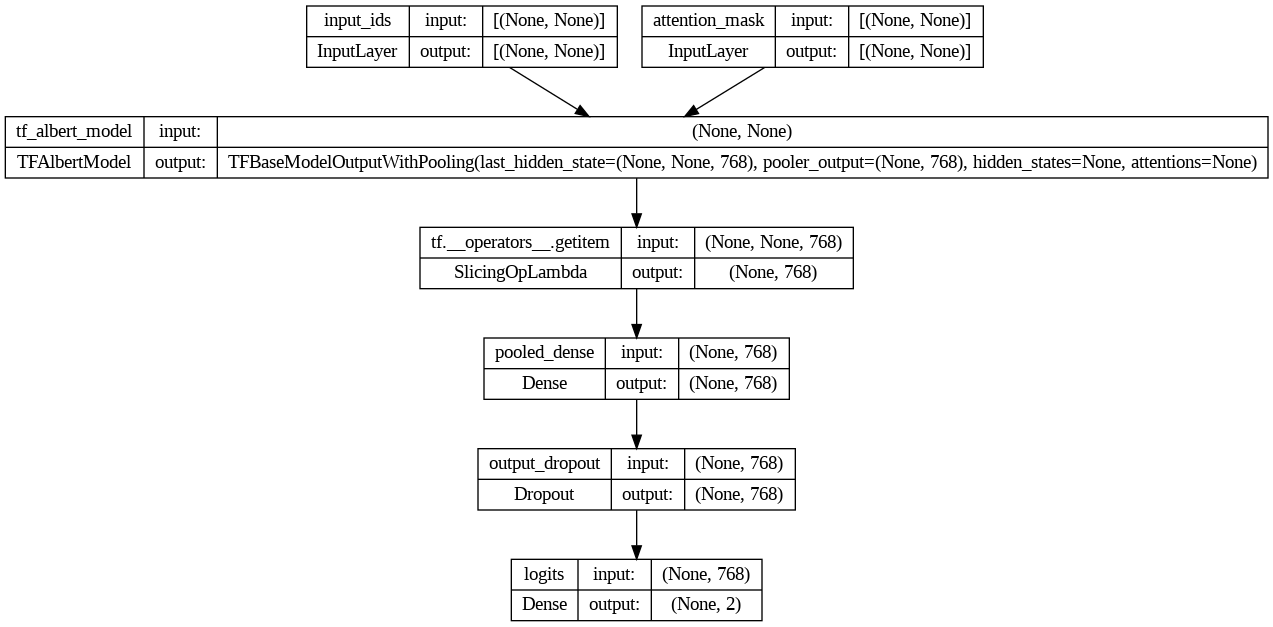

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Albert model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


139/139 [==============================] - 9s 49ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1109
           1       0.87      0.86      0.87      1111

    accuracy                           0.87      2220
   macro avg       0.87      0.87      0.87      2220
weighted avg       0.87      0.87      0.87      2220



/usr/local/lib/python3.10/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


111/111 [==============================] - 9s 52ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       866
           1       0.90      0.87      0.88       910

    accuracy                           0.88      1776
   macro avg       0.88      0.88      0.88      1776
weighted avg       0.88      0.88      0.88      1776

Validation Accuracy: 0.8680
Test Accuracy: 0.8818


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:
# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

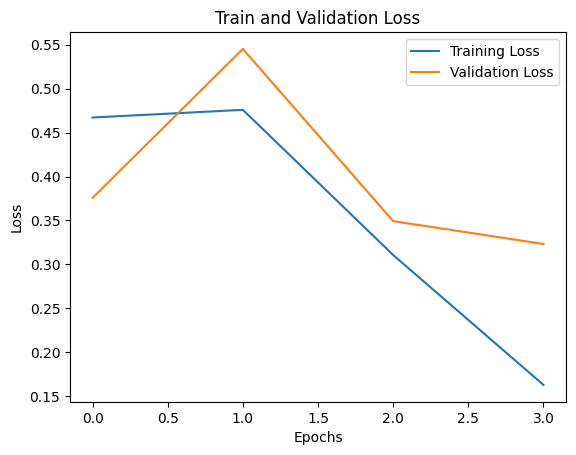

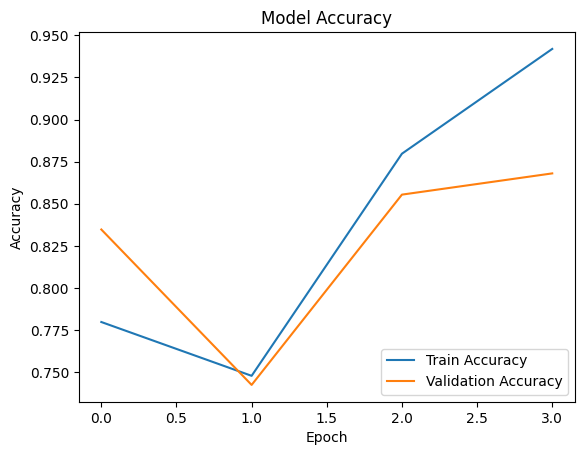

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend(loc='lower right')
# plt.show()

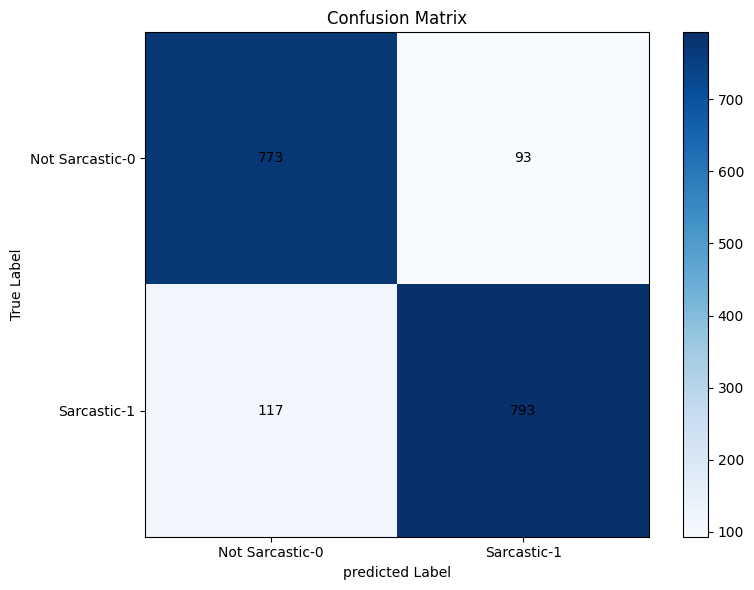

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
# plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()


cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [ ]:
# Show token IDs and the corresponding tokens for the first few examples
for i in range(5):
    print(f"Example {i + 1}:")
    print(f"Token IDs: {train_encodings['input_ids'][i]}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][i])}")
    print("-" * 20)  # Separator for clarity

Example 1:
Token IDs: [2, 7677, 31, 307, 228, 20, 107, 98, 31, 92, 120, 1452, 1028, 27, 6850, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', '▁obama', '▁i', '▁m', '▁going', '▁to', '▁do', '▁what', '▁i', '▁can', '▁through', '▁executive', '▁action', '▁on', '▁immigration', '[SEP]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
--------------------
Example 2:
Token IDs: [2, 1329, 6257, 302, 10220, 24367, 5332, 35, 65, 85, 183, 363, 189, 288, 1691, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', '▁dance', '▁cage', '▁re', 'cid', 'ivism', '▁rates', '▁at', '▁all', '▁time', '▁high', '▁within', '▁american', '▁club', '▁scene', '[SEP]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
--------------------
Example 3:
Tok

In [ ]:
# Show the attention mask for the first few examples
for i in range(5):
    print(f"Example {i + 1}:")
    print(f"Attention Mask: {train_encodings['attention_mask'][i]}")
    print("-" * 20)  # Separator for clarity


Example 1:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 2:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 3:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 4:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 5:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------


In [ ]:
# test_preds = model.predict(test_texts)
# Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
3523,0,0,let s get trump s evangelical council to resign
10016,1,1,backup health care plan involves nation sharin...
10049,1,1,woman assures friend she has blackouts from dr...
7524,0,0,a small senate victory maintains methane regul...
4240,0,0,ruth bader ginsburg abortion restrictions most...
4603,0,0,creating a chemically free home is easier and ...
7436,1,1,hillary clinton inspires young girls to form p...
2727,1,1,wrong turn finds man on poor side of mall
2066,0,0,unesco weighs in on debate over where jesus wa...
8540,1,1,compliment suspiciously vague


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

111/111 [==============================] - 5s 47ms/step


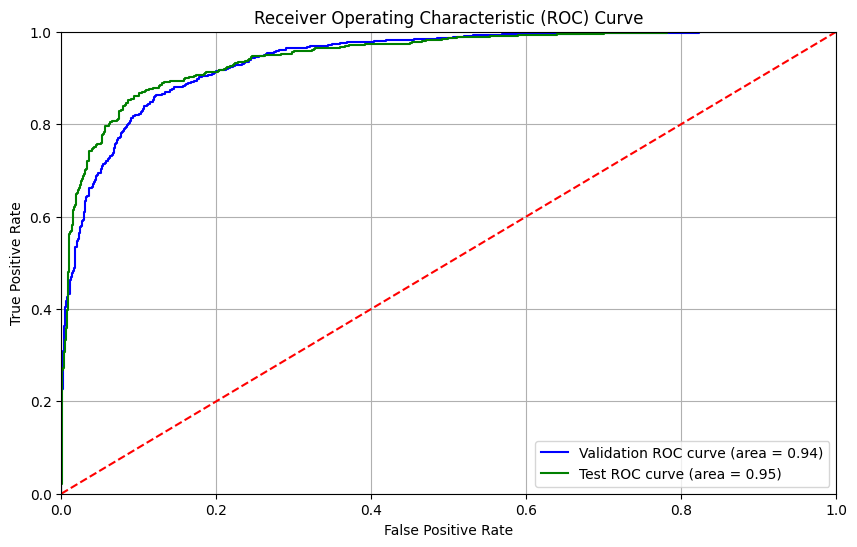

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.3233
Validation MCC: 0.7361
Validation Cohen's Kappa Score: 0.7360
Validation Brier Score: 0.0987
Test Log Loss: 0.3018
Test MCC: 0.7638
Test Cohen's Kappa Score: 0.7635
Test Brier Score: 0.0903


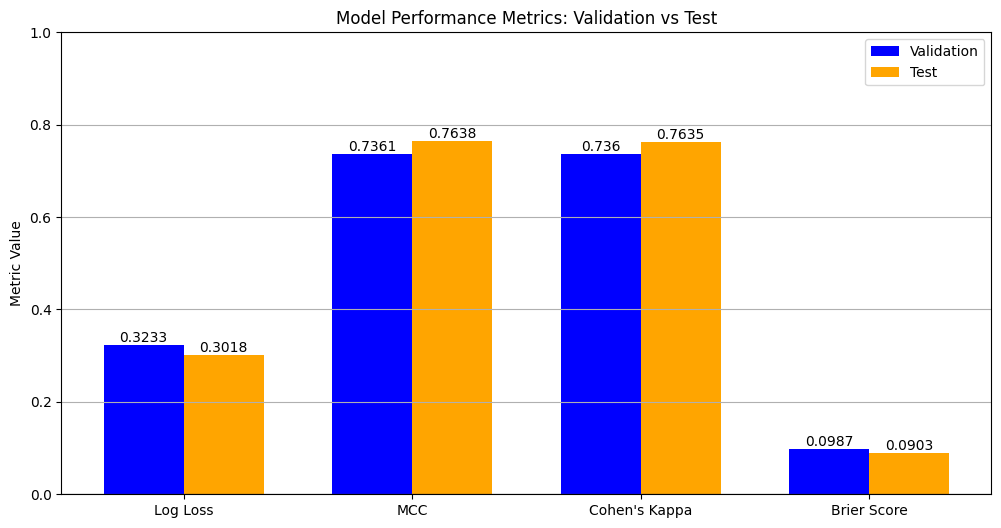

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()


# Distilbert model

In [ ]:
from transformers import DistilBertTokenizer, TFDistilBertModel
# Load DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distil_bert = TFDistilBertModel.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [ ]:
# max_length = max(len(text) for text in df['cleaned_headlines'])
# max_length

In [ ]:
# train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# # train_encodings = tokenizer(X_train.tolist(), padding=True, truncation=True, max_length=max_length)
# train_encodings
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=512)
# test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=512)
train_encodings

{'input_ids': [[101, 8112, 1045, 1049, 2183, 2000, 2079, 2054, 1045, 2064, 2083, 3237, 2895, 2006, 7521, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 9346, 2098, 3548, 2893, 1999, 2197, 24450, 20558, 2077, 2123, 1056, 3198, 2123, 1056, 2425, 21492, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2444, 11190, 6668, 3031, 2723, 1997, 1057, 1055, 2160, 1997, 4505, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 4080, 5367, 2097, 2191, 2017, 3246, 2005, 6174, 1055, 2331, 3496, 2006, 1996, 3788, 2757, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1998, 4168, 15359, 8934, 15670, 8013, 2054, 6997, 2002, 1055, 5462, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 23265, 6529, 16755, 5948, 10268, 1997, 2300, 2566, 2095, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 3539, 2704, 1997, 5120, 4152, 4201, 102, 0, 0, 0, 0, 0, 0,

In [ ]:

# test_encodings = tokenizer(X_test.tolist(), padding=True, truncation=True, max_length=max_length)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))
# train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
# test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(36,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(36,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# max_length=130

In [ ]:


# Define input layers
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

# Get the hidden states from DistilBERT backbone
hidden_states = distil_bert(input_ids, attention_mask=attention_mask).last_hidden_state

# Extract the [CLS] token representation (i.e., the first token's hidden state)
cls_token = hidden_states[:, 0, :]

# Custom dense and dropout layers
pooled_dense = tf.keras.layers.Dense(768, activation='relu', name='pooled_dense')(cls_token)
output_dropout = tf.keras.layers.Dropout(0.1, name='output_dropout')(pooled_dense)
logits = tf.keras.layers.Dense(2, name='logits')(output_dropout)

# Define the complete model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=logits)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, epsilon=1e-08)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, None, 768   0          'attention_mask[0][0]']      
                             ),                                                               

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
# loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [ ]:
# test_encodings = tokenizer(
#     X_test.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=max_length  # Use the correct max_length here
# )

In [ ]:


# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=16,
    validation_data = val_dataset.shuffle(1000).batch(16),
    callbacks=[early_stopping]
)

Epoch 1/4
444/444 [==============================] - 64s 94ms/step - loss: 0.3491 - accuracy: 0.8435 - val_loss: 0.3426 - val_accuracy: 0.8617
Epoch 2/4
444/444 [==============================] - 35s 80ms/step - loss: 0.1146 - accuracy: 0.9579 - val_loss: 0.3687 - val_accuracy: 0.9041
Epoch 3/4
444/444 [==============================] - 36s 80ms/step - loss: 0.0369 - accuracy: 0.9875 - val_loss: 0.4924 - val_accuracy: 0.8932
Epoch 4/4
444/444 [==============================] - 35s 80ms/step - loss: 0.0298 - accuracy: 0.9894 - val_loss: 0.4492 - val_accuracy: 0.8928


In [ ]:
# model.summary()

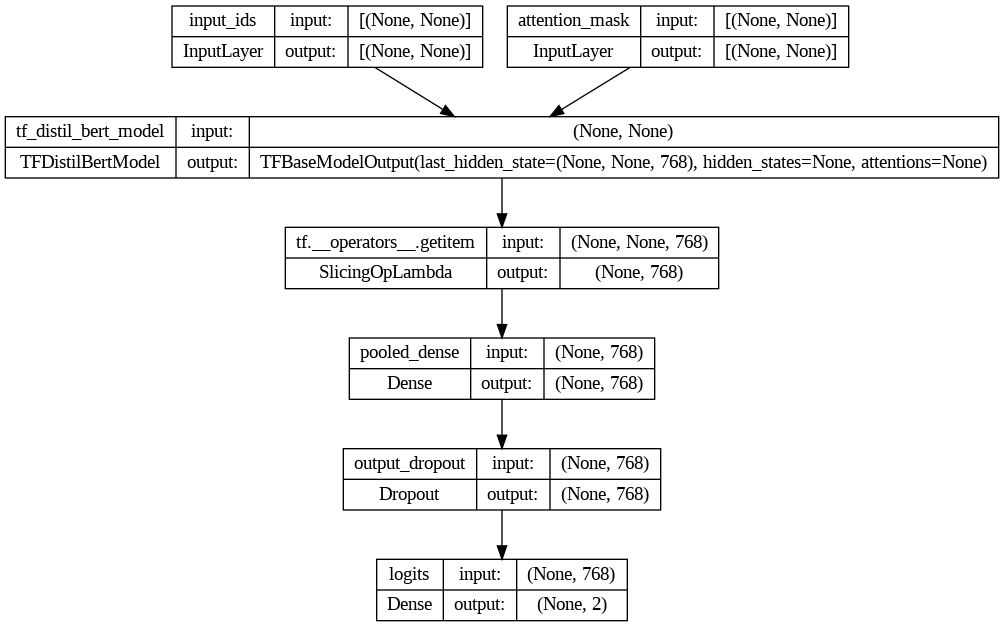

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Distilbert model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


139/139 [==============================] - 5s 23ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1109
           1       0.95      0.76      0.85      1111

    accuracy                           0.86      2220
   macro avg       0.88      0.86      0.86      2220
weighted avg       0.88      0.86      0.86      2220

111/111 [==============================] - 4s 25ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       866
           1       0.96      0.79      0.87       910

    accuracy                           0.88      1776
   macro avg       0.89      0.88      0.87      1776
weighted avg       0.89      0.88      0.87      1776

Validation Accuracy: 0.8617
Test Accuracy: 0.8750


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:

# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

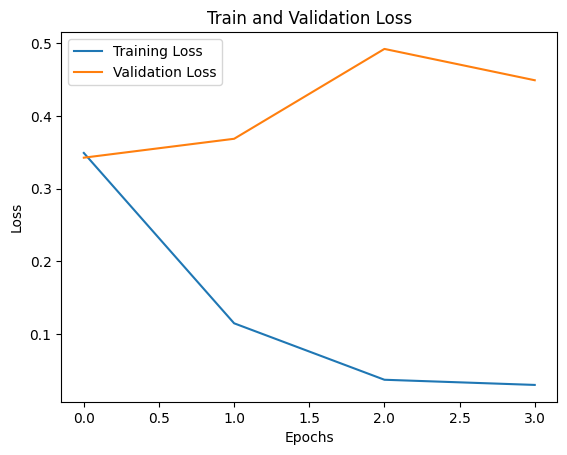

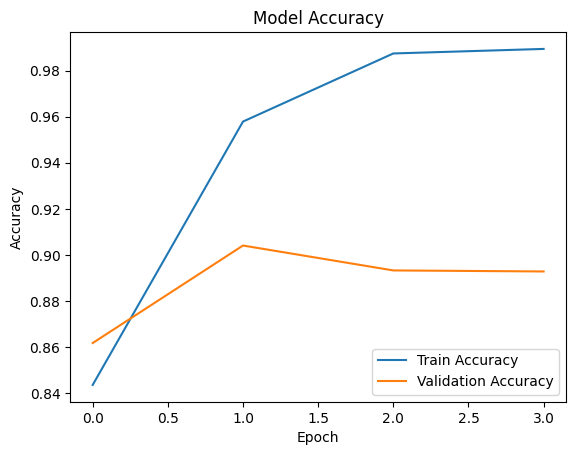

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

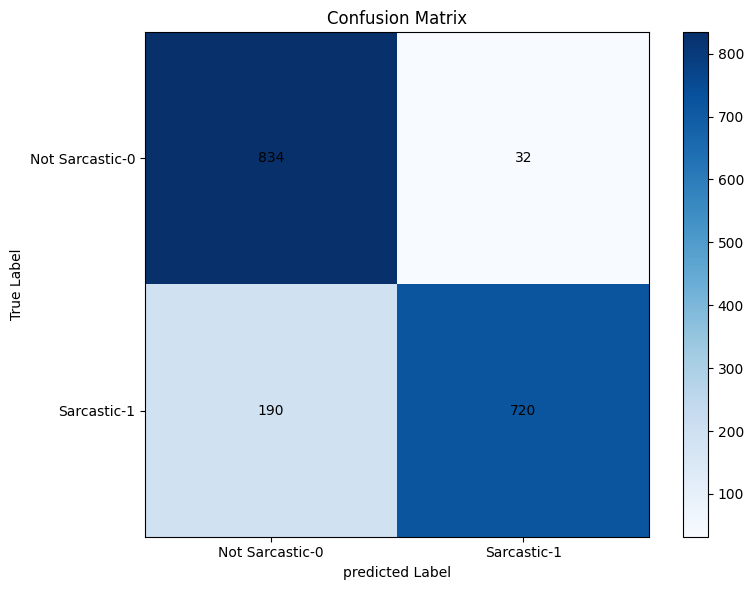

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming 'test_labels' and 'test_preds' are your true and predicted labels for the test set
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])
# plt.yticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

In [ ]:
# # test_preds = model.predict(test_texts)
# # Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
# Create a DataFrame with true and predicted labels
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
3523,0,0,let s get trump s evangelical council to resign
10016,1,1,universe ends as god wakes up next to suzanne ...
10049,1,1,nation savoring every moment of glorious late ...
7524,0,0,a small senate victory maintains methane regul...
4240,0,0,ruth bader ginsburg abortion restrictions most...
4603,0,0,creating a chemically free home is easier and ...
7436,1,0,hillary clinton inspires young girls to form p...
2727,1,1,wrong turn finds man on poor side of mall
2066,0,0,unesco weighs in on debate over where jesus wa...
8540,1,1,compliment suspiciously vague


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

111/111 [==============================] - 3s 29ms/step


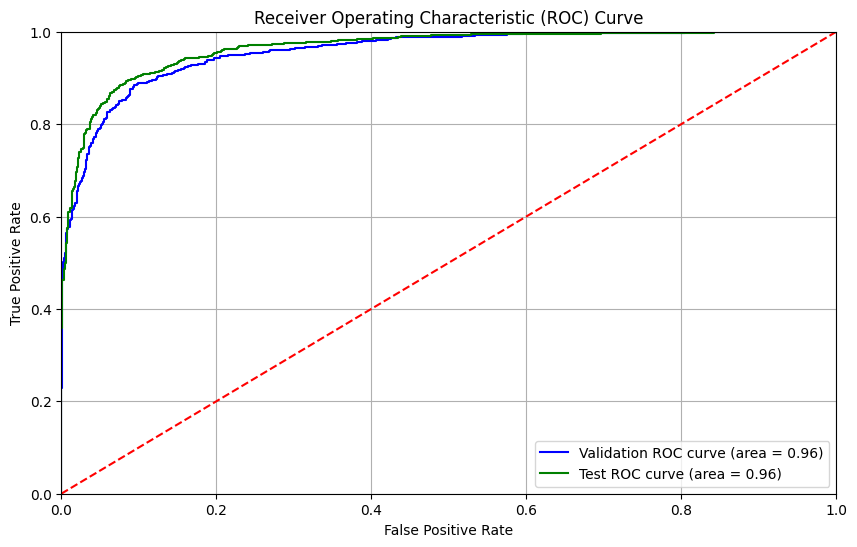

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.3426
Validation MCC: 0.7377
Validation Cohen's Kappa Score: 0.7235
Validation Brier Score: 0.1004
Test Log Loss: 0.3194
Test MCC: 0.7630
Test Cohen's Kappa Score: 0.7509
Test Brier Score: 0.0927


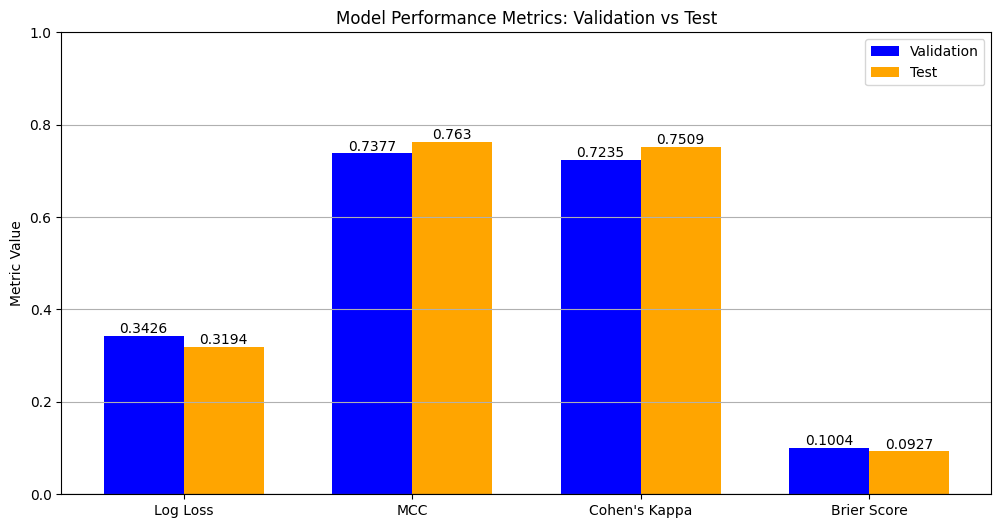

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()
